# Imports

In [28]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.cluster import KMeans , AgglomerativeClustering ,DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

# Load Data

In [29]:
df=pd.read_csv(r"C:\Users\Pranjali kiran Bokad\Downloads\Mall_Customers.csv")

In [30]:
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Data Overview

In [31]:
df.shape

(200, 5)

In [32]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [34]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(0)

# Visualization and EDA

In [36]:
numeric_cols=df.select_dtypes(include=["int64","float64"]).columns
print(numeric_cols)

Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')


In [37]:
cat_cols=df.select_dtypes(include="object").columns
print(cat_cols)

Index(['Gender'], dtype='object')


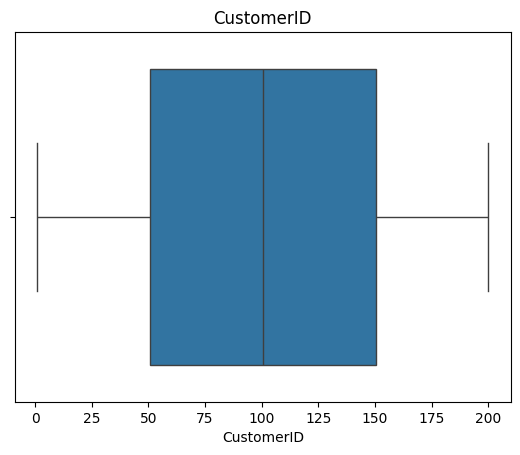

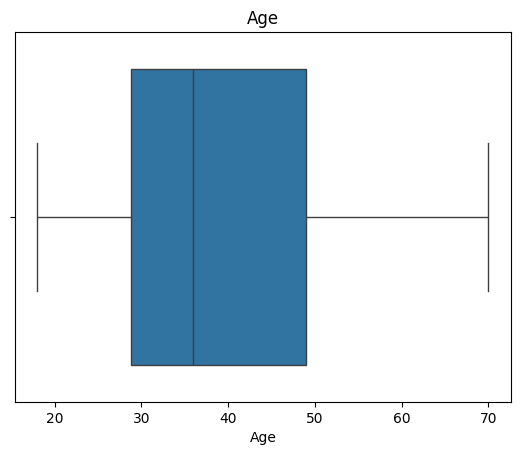

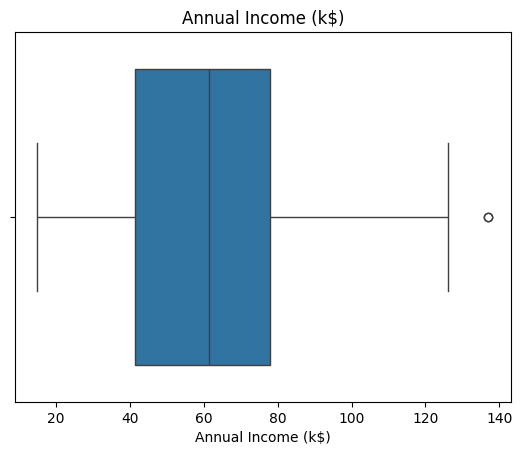

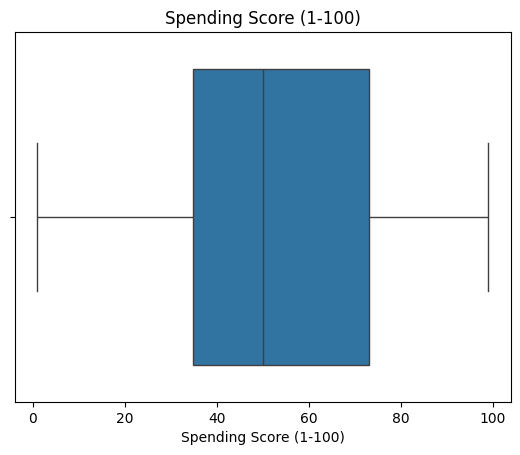

In [38]:
for i in df.select_dtypes(include=["int64","float64"]).columns:
    sns.boxplot(x=i,data=df)
    plt.title(i)
    plt.show()

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_16632\3038315720.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


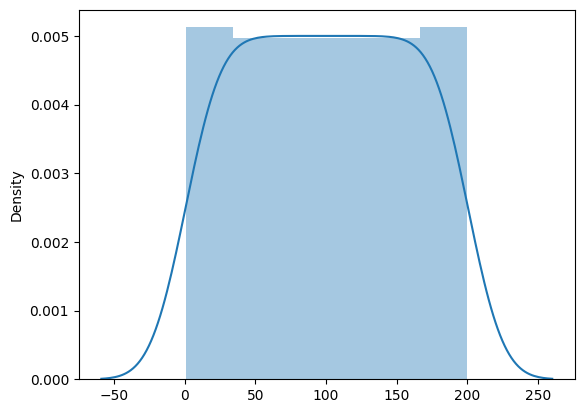

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_16632\3038315720.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


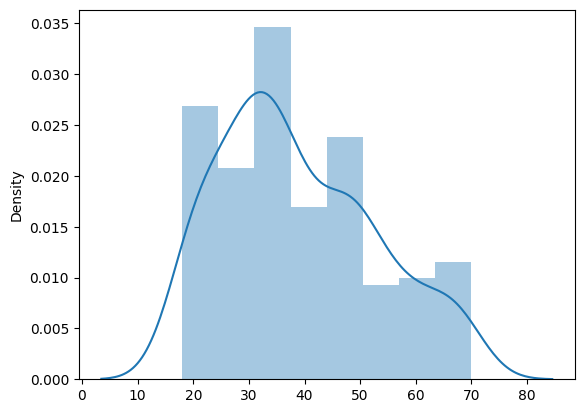

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_16632\3038315720.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


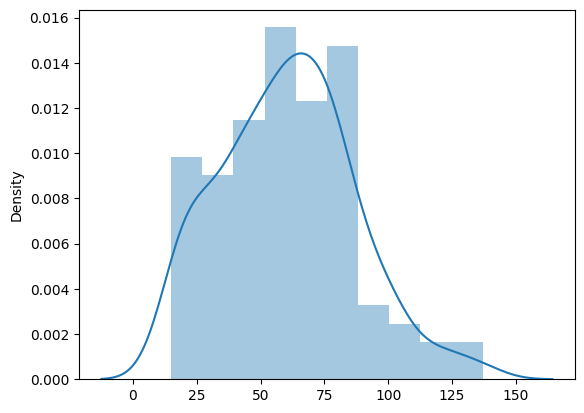

C:\Users\Pranjali kiran Bokad\AppData\Local\Temp\ipykernel_16632\3038315720.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df[i])


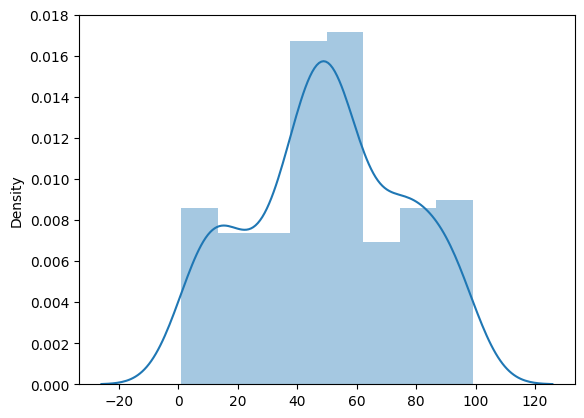

In [39]:
for i in df.select_dtypes(include=["int64","float64"]).columns:
    sns.distplot(x=df[i])
    plt.show()

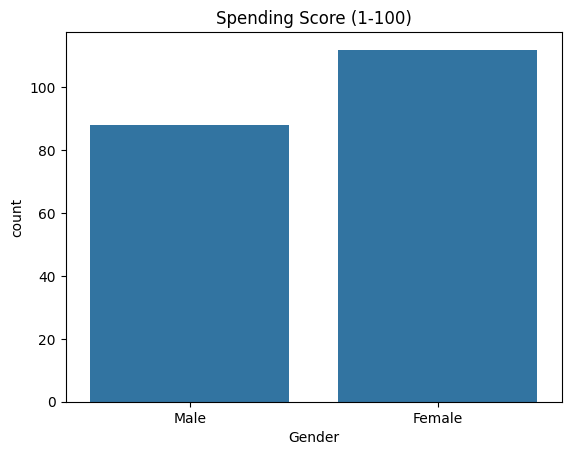

In [40]:
sns.countplot(x=df["Gender"])
plt.xticks(rotation=0)
plt.title(i)
plt.show()

# Correlation Heatmap

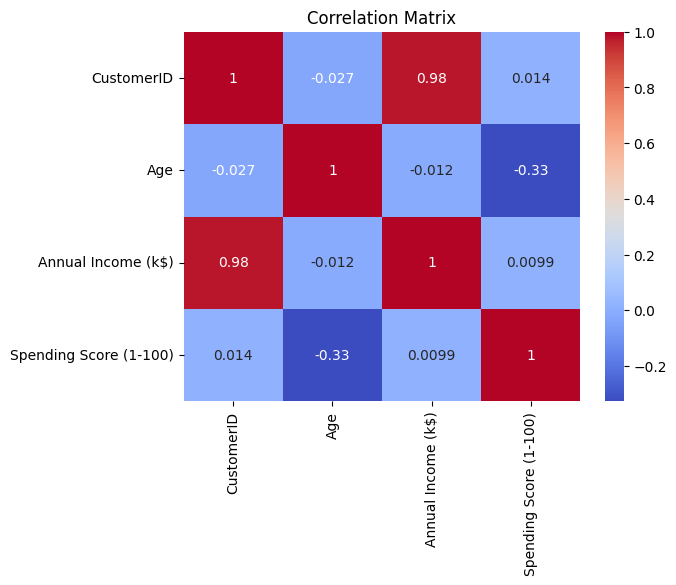

In [41]:
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Preprocessing

In [42]:
df=df.drop(columns=["CustomerID","Gender","Age"],axis=1)

In [43]:
numeric_cols=['Annual Income (k$)', 'Spending Score (1-100)']

In [44]:
std=StandardScaler()
X_scaled=std.fit_transform(df[numeric_cols])

In [45]:
X=X_scaled

# Elbow Method

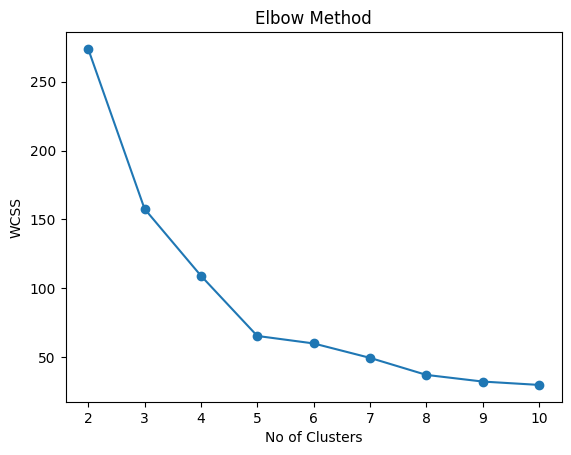

In [46]:
wcss=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,11),wcss,marker='o')
plt.xlabel("No of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# Model Comparision

In [47]:
for i in range(2,11):
  agg = AgglomerativeClustering(n_clusters=i)
  agg_labels=agg.fit_predict(X)
  print(f"Agglomerative K={i}:{silhouette_score(X,agg_labels):4f}")

for k in range(2,11):
  gmm = GaussianMixture(n_components=k,random_state=42)
  gmm_labels=gmm.fit_predict(X)
  print(f"GMM K={k}:{silhouette_score(X,gmm_labels):4f}")

for j in range(2,11):
  km = KMeans(n_clusters=j,n_init=10,random_state=42)
  km_labels=km.fit_predict(X)
  kmeans_score=silhouette_score(X,km_labels)
  print(f"Kmeans j={j}: {kmeans_score:.4f}")

Agglomerative K=2:0.384234
Agglomerative K=3:0.461048
Agglomerative K=4:0.492551
Agglomerative K=5:0.553809
Agglomerative K=6:0.538676
Agglomerative K=7:0.519795
Agglomerative K=8:0.430862
Agglomerative K=9:0.437690
Agglomerative K=10:0.433901
GMM K=2:0.379082
GMM K=3:0.430190
GMM K=4:0.413392
GMM K=5:0.553689
GMM K=6:0.516982
GMM K=7:0.509057
GMM K=8:0.430210
GMM K=9:0.423282
GMM K=10:0.415309
Kmeans j=2: 0.3213
Kmeans j=3: 0.4666
Kmeans j=4: 0.4939
Kmeans j=5: 0.5547
Kmeans j=6: 0.5399
Kmeans j=7: 0.5281
Kmeans j=8: 0.4552
Kmeans j=9: 0.4571
Kmeans j=10: 0.4432


# Final Model

In [48]:
km_final = KMeans(n_clusters=6,n_init=10,random_state=42)
df["Cluster"]=km_final.fit_predict(X_scaled)

score=silhouette_score(X,df["Cluster"])
print(f"Silhouette Score:{score}")

Silhouette Score:0.5398800926790663


# Cluster Profile

In [49]:
df.groupby("Cluster")[["Annual Income (k$)","Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,88.200000,17.114286
2,109.700000,82.000000
3,26.304348,20.913043
4,25.727273,79.363636
5,78.551724,82.172414


# PCA Visualization

Varience Ratio:[0.50495142 0.49504858]
Total Varience captured:100.00%


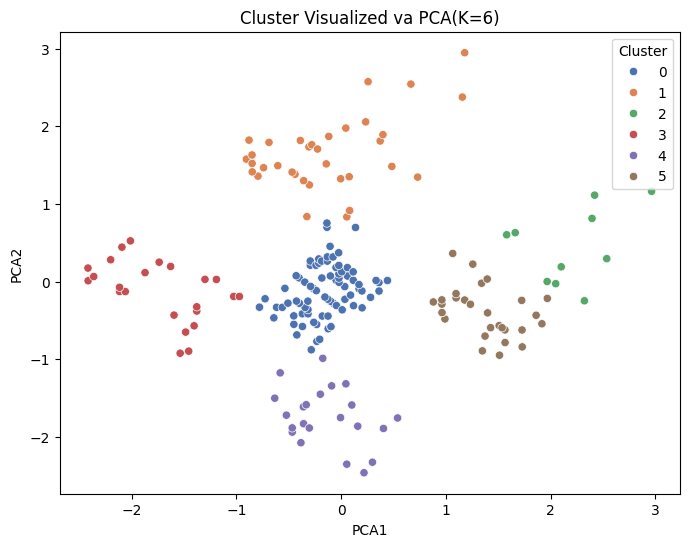

In [50]:
pca = PCA(n_components=2,random_state=42)
X_pca=pca.fit_transform(X_scaled)

df["PCA1"]=X_pca[:,0]
df["PCA2"]=X_pca[:,1]

print(f"Varience Ratio:{pca.explained_variance_ratio_}")
print(f"Total Varience captured:{sum(pca.explained_variance_ratio_):.2%}")

plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x="PCA1",y="PCA2",hue="Cluster",palette="deep")
plt.title("Cluster Visualized va PCA(K=6)")
plt.show()

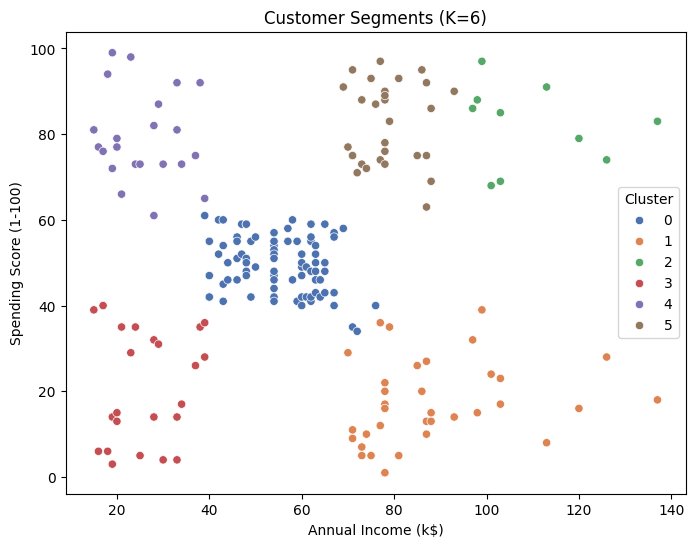

In [51]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='Cluster',palette='deep')
plt.title("Customer Segments (K=6)")
plt.show()